Exploratory data analysis (EDA) is a crucial component of data science which allows you to understand the basics of what your data looks like and what kinds of questions might be answered. For this task, we are going to clean, sanitise and explore our data. Using the automobile dataset, complete the steps outlined in this notebook by writing code in the cells.

In [638]:
# Import libraries

import numpy as np
import pandas as pd
import seaborn as sns

from datetime import datetime
import matplotlib.pyplot as plt
%matplotlib inline

In [639]:
# Load the automobiles dataset
automobiles_df = pd.read_csv('automobile.txt')
df = automobiles_df
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


### Data Cleansing
#### Clean the data

Identify columns that are redundant or unnecessary. It is always easier to make your decisions based on data which is relevant and concise. Remove the following columns `['normalized-losses', 'symboling']` from the data set as they will not be used in the analysis.

In [640]:
df = df.drop(columns=["normalized-losses", "symboling"])
df.head()

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


#### Remove any duplicate rows

In [641]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


#### Remove rows with missing data

Some automobiles in the database have missing values which implies that their values have not been recorded or some information is missing. Discard such entries from the dataframe.

In [642]:
# "?" has been recorded, but should be replaced then removed
df.replace("?", np.nan, inplace=True)

print(df.isnull().sum())

make                 0
fuel-type            0
aspiration           0
num-of-doors         2
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 4
stroke               4
compression-ratio    0
horsepower           2
peak-rpm             2
city-mpg             0
highway-mpg          0
price                4
dtype: int64


In [643]:
# Drop the rows with missing "NaN"
df.dropna(inplace=True)

# Check for rows with missing values again
print(df.isnull().sum())

make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64


Change columns with numerical data column to an integer data type using numpy’s `int64` method.

In [644]:
# Check dtypes
df.dtypes

make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                     str
stroke                   str
compression-ratio    float64
horsepower               str
peak-rpm                 str
city-mpg               int64
highway-mpg            int64
price                    str
dtype: object

In [645]:
# The necessary columns to change from str to int64 
# are as follows
numeric_columns = [
    "price",
    "horsepower",
    "peak-rpm",
    "stroke",
    "bore",
    "curb-weight", 
    "wheel-base", 
    "length", 
    "width", 
    "height", 
    "compression-ratio"
]

df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric)

# Round the values
df[numeric_columns] = df[numeric_columns].round()

# Convert to int64
df[numeric_columns] = df[numeric_columns].astype("int64")

df.info()

<class 'pandas.DataFrame'>
Index: 193 entries, 0 to 204
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   make               193 non-null    str  
 1   fuel-type          193 non-null    str  
 2   aspiration         193 non-null    str  
 3   num-of-doors       193 non-null    str  
 4   body-style         193 non-null    str  
 5   drive-wheels       193 non-null    str  
 6   engine-location    193 non-null    str  
 7   wheel-base         193 non-null    int64
 8   length             193 non-null    int64
 9   width              193 non-null    int64
 10  height             193 non-null    int64
 11  curb-weight        193 non-null    int64
 12  engine-type        193 non-null    str  
 13  num-of-cylinders   193 non-null    str  
 14  engine-size        193 non-null    int64
 15  fuel-system        193 non-null    str  
 16  bore               193 non-null    int64
 17  stroke             193 non-null 

In [646]:
# Look at how the data appears in the df now
df.head()

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,alfa-romero,gas,std,two,convertible,rwd,front,89,169,64,...,130,mpfi,3,3,9,111,5000,21,27,13495
1,alfa-romero,gas,std,two,convertible,rwd,front,89,169,64,...,130,mpfi,3,3,9,111,5000,21,27,16500
2,alfa-romero,gas,std,two,hatchback,rwd,front,94,171,66,...,152,mpfi,3,3,9,154,5000,19,26,16500
3,audi,gas,std,four,sedan,fwd,front,100,177,66,...,109,mpfi,3,3,10,102,5500,24,30,13950
4,audi,gas,std,four,sedan,4wd,front,99,177,66,...,136,mpfi,3,3,8,115,5500,18,22,17450


In [647]:
# Change the name "alfa-romero" to the
# correct name "alfa-romeo"
df["make"] = df["make"].replace("alfa-romero", "alfa-romeo")

df.head()

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,alfa-romeo,gas,std,two,convertible,rwd,front,89,169,64,...,130,mpfi,3,3,9,111,5000,21,27,13495
1,alfa-romeo,gas,std,two,convertible,rwd,front,89,169,64,...,130,mpfi,3,3,9,111,5000,21,27,16500
2,alfa-romeo,gas,std,two,hatchback,rwd,front,94,171,66,...,152,mpfi,3,3,9,154,5000,19,26,16500
3,audi,gas,std,four,sedan,fwd,front,100,177,66,...,109,mpfi,3,3,10,102,5500,24,30,13950
4,audi,gas,std,four,sedan,4wd,front,99,177,66,...,136,mpfi,3,3,8,115,5500,18,22,17450


### Finding Certain Categories
Locate all automobiles in the "hatchback" genre.

In [648]:
# Create a dataframe with all the cars in the "hatchback' category
hatchback_cars = df[df["body-style"] == "hatchback"]

hatchback_cars.head()

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
2,alfa-romeo,gas,std,two,hatchback,rwd,front,94,171,66,...,152,mpfi,3,3,9,154,5000,19,26,16500
18,chevrolet,gas,std,two,hatchback,fwd,front,88,141,60,...,61,2bbl,3,3,10,48,5100,47,53,5151
19,chevrolet,gas,std,two,hatchback,fwd,front,94,156,64,...,90,2bbl,3,3,10,70,5400,38,43,6295
21,dodge,gas,std,two,hatchback,fwd,front,94,157,64,...,90,2bbl,3,3,9,68,5500,37,41,5572
22,dodge,gas,std,two,hatchback,fwd,front,94,157,64,...,90,2bbl,3,3,9,68,5500,31,38,6377


### Now onto the exploration

#### Identify relationships between variables (features)

The main goal here is to identify and create relationships that can help you formulate ideas. We have defined questions to help you identify some relationships to explore.

#### Which are the 5 most expensive cars?

How do the most expensive and cheapest cars compare? Exploring the most expensive cars highlights if some moviecars are worth the money spent on them based on their fuel economy (mpg or miles per gallon)

In [649]:
# Get the 5 most expensive cars
most_expensive = df.sort_values(by="price", ascending=False).head(5)

print("Five Most Expensive Cars:\n")
print(most_expensive[["make", "price"]])


Five Most Expensive Cars:

              make  price
74   mercedes-benz  45400
16             bmw  41315
73   mercedes-benz  40960
128        porsche  37028
17             bmw  36880


In [650]:
# Get the 5 cheapest cars
cheapest = df.sort_values(by="price", ascending=True).head(5)

print("Five Cheapest Cars:\n")
print(cheapest[["make", "price"]])

Five Cheapest Cars:

           make  price
138      subaru   5118
18    chevrolet   5151
50        mazda   5195
150      toyota   5348
76   mitsubishi   5389


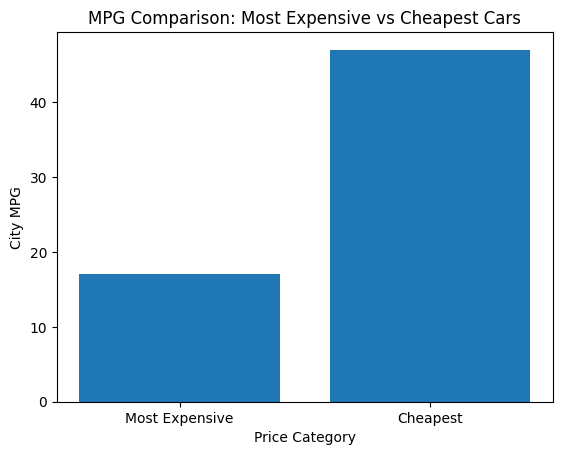

In [651]:
# Compare the fuel efficiency of the most
# expensive and the cheapest cars using "city-mpg"

# Make a new df for this
most_expensive["category"] = "Most Expensive"
cheapest["category"] = "Cheapest"

compared_df = pd.concat([most_expensive, cheapest])

# Plot figure to display the comparison
plt.figure()

plt.bar(compared_df["category"], compared_df["city-mpg"])

plt.xlabel("Price Category")
plt.ylabel("City MPG")
plt.title("MPG Comparison: Most Expensive vs Cheapest Cars")

plt.show()

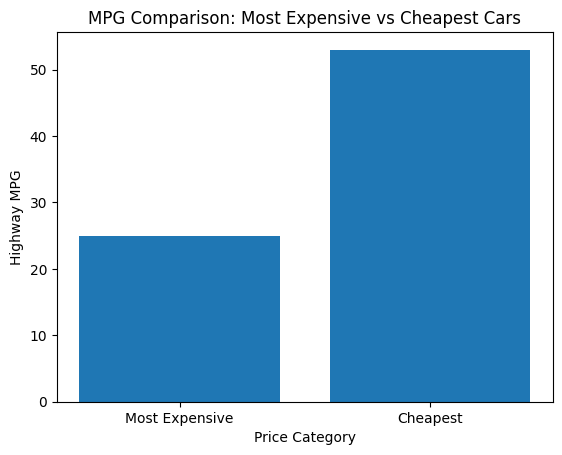

In [652]:
# Compare the fuel efficiency of the most
# expensive and the cheapest cars using "highway-mpg"

# Make a new df for this
most_expensive["category"] = "Most Expensive"
cheapest["category"] = "Cheapest"

compared_df = pd.concat([most_expensive, cheapest])

# Plot figure to display the comparison
plt.figure()

plt.bar(compared_df["category"], compared_df["highway-mpg"])

plt.xlabel("Price Category")
plt.ylabel("Highway MPG")
plt.title("MPG Comparison: Most Expensive vs Cheapest Cars")

plt.show()

In [653]:
# Show physical factors of the most expensive 
# and cheapest cars

print("Most Expensive:\n")
print(most_expensive[["make", "curb-weight", "length", 
    "width", "height", "body-style"]])
print("")

print("\nCheapest:\n")
print(cheapest[["make", "curb-weight", "length", 
    "width", "height", "body-style"]])

Most Expensive:

              make  curb-weight  length  width  height   body-style
74   mercedes-benz         3715     199     72      55      hardtop
16             bmw         3380     194     68      54        sedan
73   mercedes-benz         3900     208     72      57        sedan
128        porsche         2800     169     65      52  convertible
17             bmw         3505     197     71      56        sedan


Cheapest:

           make  curb-weight  length  width  height body-style
138      subaru         2050     157     63      54  hatchback
18    chevrolet         1488     141     60      53  hatchback
50        mazda         1890     159     64      54  hatchback
150      toyota         1985     159     64      54  hatchback
76   mitsubishi         1918     157     64      51  hatchback


In [654]:
# Show engine size and horsepower of the most expensive 
# and cheapest cars

print("Most Expensive:\n")
print(most_expensive[["make", "engine-size", "horsepower"]])
print("")

print("\nCheapest:\n")
print(cheapest[["make", "engine-size", "horsepower"]])

Most Expensive:

              make  engine-size  horsepower
74   mercedes-benz          304         184
16             bmw          209         182
73   mercedes-benz          308         184
128        porsche          194         207
17             bmw          209         182


Cheapest:

           make  engine-size  horsepower
138      subaru           97          69
18    chevrolet           61          48
50        mazda           91          68
150      toyota           92          62
76   mitsubishi           92          68


#### Which manufacturer builds the most fuel efficient vehicles?

Compare the average mpg for each vehicle manufacture's vehicles and create a bar plot

In [655]:
# Calculate average city mpg for each make

avg_city_mpg = df.groupby("make")["city-mpg"].mean()

avg_city_mpg = avg_city_mpg.sort_values(ascending=False)

avg_city_mpg = avg_city_mpg.head(10)

print(avg_city_mpg)

make
chevrolet     41.000000
honda         30.384615
volkswagen    28.583333
dodge         28.500000
plymouth      28.142857
mazda         27.833333
toyota        27.500000
nissan        27.000000
subaru        26.333333
mitsubishi    24.923077
Name: city-mpg, dtype: float64


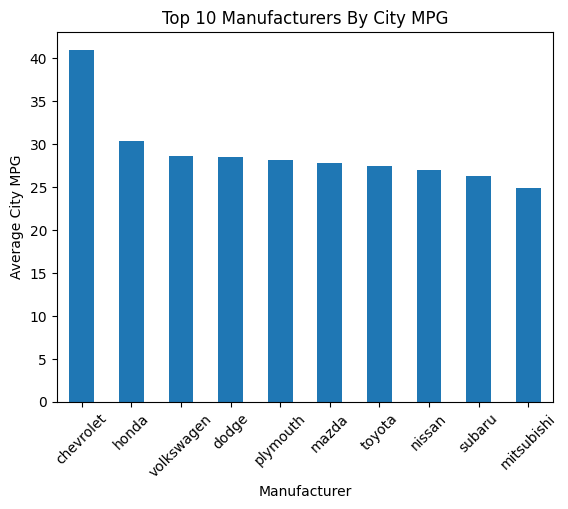

In [656]:
# Create bar chart to show average city mpg for each 
# manufacturer

plt.figure()

avg_city_mpg.plot(kind="bar")

plt.xlabel("Manufacturer")
plt.ylabel("Average City MPG")
plt.title("Top 10 Manufacturers By City MPG")

plt.xticks(rotation=45)

plt.show()

In [657]:
# Calculate average highway mpg for each make

avg_highway_mpg = df.groupby("make")["highway-mpg"].mean()

avg_highway_mpg = avg_highway_mpg.sort_values(ascending=False)

avg_highway_mpg = avg_highway_mpg.head(10)

print(avg_highway_mpg)

make
chevrolet     46.333333
honda         35.461538
volkswagen    34.916667
dodge         34.625000
plymouth      34.142857
mazda         34.083333
nissan        32.944444
toyota        32.906250
mitsubishi    31.153846
subaru        30.750000
Name: highway-mpg, dtype: float64


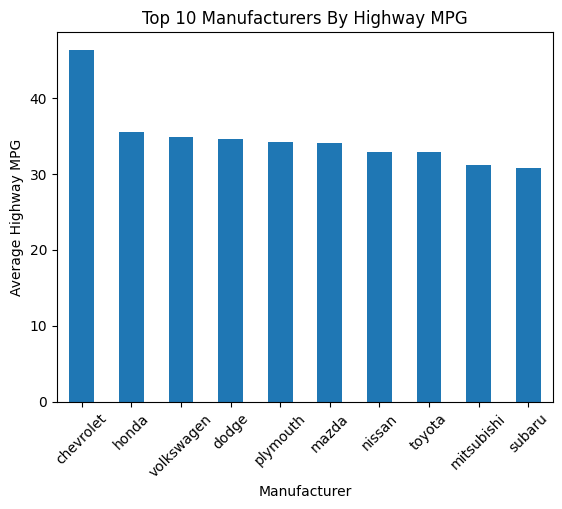

In [658]:
# Create bar chart to show average city mpg for each 
# manufacturer

plt.figure()

avg_highway_mpg.plot(kind="bar")

plt.xlabel("Manufacturer")
plt.ylabel("Average Highway MPG")
plt.title("Top 10 Manufacturers By Highway MPG")

plt.xticks(rotation=45)

plt.show()

#### Which vehicles have the largest engine capacity.
Sort the dataframe based on the engine-size column.

In [659]:
# Sort makes by engine size
engine_sorted = df.sort_values(by="engine-size")

print(engine_sorted[["make", "engine-size"]])


             make  engine-size
18      chevrolet           61
32          honda           79
21          dodge           90
25          dodge           90
19      chevrolet           90
..            ...          ...
47         jaguar          258
48         jaguar          258
74  mercedes-benz          304
73  mercedes-benz          308
49         jaguar          326

[193 rows x 2 columns]


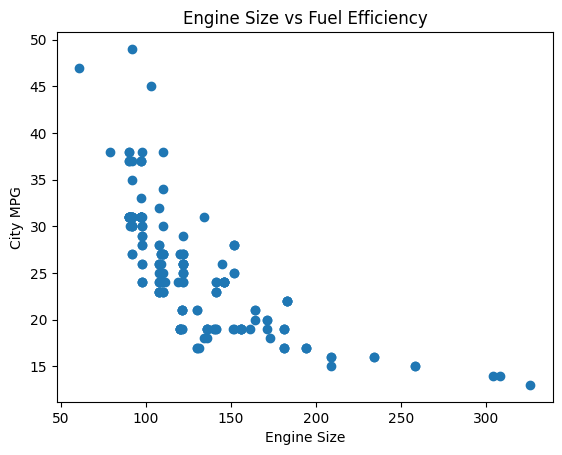

In [660]:
# Create scatter plot showing engine size vs city mpg

plt.figure()

plt.scatter(df["engine-size"], df["city-mpg"])

plt.xlabel("Engine Size")
plt.ylabel("City MPG")
plt.title("Engine Size vs Fuel Efficiency")

plt.show()

#### Which vehicle manufacturer has the most car models in the dataset

In [661]:
# Show which manufacturer has the most cars in the dataset
make_counts = df["make"].value_counts()

print(make_counts)

make
toyota           32
nissan           18
honda            13
mitsubishi       13
mazda            12
subaru           12
volkswagen       12
peugot           11
volvo            11
bmw               8
dodge             8
mercedes-benz     8
plymouth          7
audi              6
saab              6
porsche           4
alfa-romeo        3
chevrolet         3
jaguar            3
isuzu             2
mercury           1
Name: count, dtype: int64


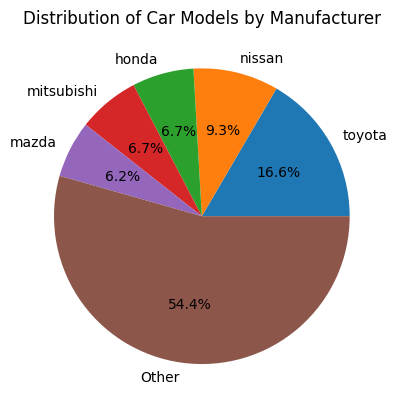

In [662]:
# Plot pie chart to show the 5 manufacturers with the most
# cars in the dataset as well as the rest of the manufacturers

top_5 = make_counts.head(5)

other = make_counts[5:].sum()

top_5["Other"] = other

plt.figure()

plt.pie(
    top_5,
    labels=top_5.index,
    autopct="%1.1f%%"
)

plt.title("Distribution of Car Models by Manufacturer")

plt.show()

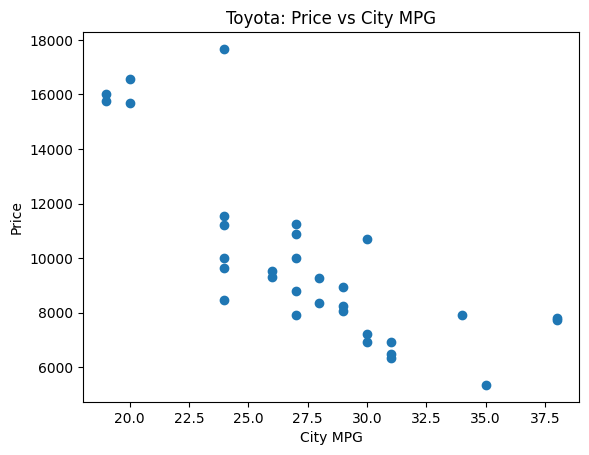

In [663]:
# Create scatter plot to show price vs city mpg for Toyota

toyota_df = df[df["make"] == "toyota"]

plt.figure()

plt.scatter(
    toyota_df["city-mpg"],
    toyota_df["price"]
)

plt.xlabel("City MPG")
plt.ylabel("Price")
plt.title("Toyota: Price vs City MPG")

plt.show()